# 데이터 전처리(Data Preprocessing) 개념 정리

1. 데이터 전처리 정의 및 목적  
 - 정의: 원시 데이터(raw data)를 분석 및 머신러닝에 적합한 형태 변환
 - 목적: 데이터 품질 향상, 분석/모델링 과정 오류 최소화 및 정확한 결과 도출

2. 데이터 전처리  작업
 - 정제(Cleansing)
    - 결측치 처리: 
        - 개념: 누락된 값(Missing values) 식별 및 삭제/대체
        - 식별: 단순 탐색, 시각화, 결측치 패턴 분석
        - 처리: 삭제, 평균/중앙값/최빈값 대체, 전진/후진 채우기, 임의 값, KNN/회귀/다중 대체
    - 이상치 처리: 
        - 개념 :  다른 데이터 포인트와 현저히 차이 나는 값 처리
        - 식별: IQR 방법, 박스플롯(Boxplot) 사용, 상한선/하한선 설정
        - 처리: 이상치 제거, 평균/중앙값/최빈값 대체, 로그/제곱근 변환, 클리핑(Clipping), 회귀 모델/KNN 대체
    - 중복 데이터 제거: 동일 데이터 레코드 정리
 - 통합(Integration): 
    - 개념: 분석을 위한 여러 데이터원 통합
 - 변환(Transformation)
    - 데이터 분포 정상화, 범위 표준화, 이상치 영향 감소 등을 목적으로 다루기 쉬운 형식 변환
    - 척도 맞추기 작업, 스케일링, 정규화, 범주형 데이터 인코딩
 - 데이터 축소(Reduction): 차원(변수) 축소, 샘플링
 - 특징 선택 및 생성(Feature Selection & Engineering): 모델 성능 향상을 위한 주요 특징(변수) 선택 및 생성   


Seaborn의 titanic 데이터셋과 Scikit-learn 라이브러리를 활용해 전처리 전 과정을 구현한 예시 코드입니다.


In [ ]:
# 폴더가 없을 때만 새로 생성
# import os


# def create_folder_if_not_exists(folder_path):
#   # 폴더 존재 여부 확인 (검색)
#   if not os.path.exists(folder_path):
#     # 폴더가 없으면 생성 (상위 폴더까지 필요시 자동 생성)
#     os.makedirs(folder_path)
#     print(f"폴더가 존재하지 않아 새로 생성했습니다: {folder_path}")
#   else:
#     print(f"이미 존재하는 폴더입니다: {folder_path}")


# # 사용 예시
# target_folder = "./model"
# create_folder_if_not_exists(target_folder)

## 1. Titanic 데이터셋 (seaborn)
- 전처리: 중복제거, IQR 기준 클리핑(이상치), StandardScaler 스케일링, PCA 차원 축소

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 데이터 로드
df = sns.load_dataset("titanic")


# ==========================================
# 1. 정제 (Cleansing)
# ==========================================

# 1-1. 결측치 처리
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# 1-2. 이상치 처리 (IQR 클리핑)
q1 = df["fare"].quantile(0.25)
q3 = df["fare"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
df["fare"] = np.clip(df["fare"], lower_bound, upper_bound) # 이 범위를 벗어나는 것들은 버려라 -> 이상치값 버림

# 1-3. 중복 데이터 제거 및 인덱스 재정렬 (중요: 인덱스 불일치 방지)
df = df.drop_duplicates().reset_index(drop=True)# drop=True -> 기존 인덱스값 다 버림


# ==========================================
# 2. 변환 (Transformation)
# ==========================================

# 2-1. 범주형 데이터 인코딩 (One-Hot Encoding)
encoder = OneHotEncoder(sparse_output=False, drop="first")
encoded_sex = encoder.fit_transform(df[["sex"]])
encoded_sex_df = pd.DataFrame(
    encoded_sex, columns=encoder.get_feature_names_out(["sex"])
)

# 2-2. 스케일링 및 정규화
scaler = StandardScaler()
df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(df[["age", "fare"]])


# ==========================================
# 3. 특징 선택 및 생성 (Feature Engineering)
# ==========================================

# 파생 변수 생성: 실제 존재하지 않는 컬럼 , 필요에 의해 생성함
df["family_size"] = df["sibsp"] + df["parch"] + 1

# 전처리 완료된 특징 및 타겟 결합
X_features = pd.concat(
    [df[["age_scaled", "fare_scaled", "family_size"]], encoded_sex_df], axis=1
)
y = df["survived"]


# ==========================================
# 4. 데이터 축소 및 분할 (Reduction & Split)
# ==========================================

# Train / Test 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42
)

# 차원 축소 (PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("전처리 완료 데이터 크기:", X_features.shape)
print("PCA 축소 후 Train 데이터 크기:", X_train_pca.shape)


# ==========================================
# 5. 모델 학습 & 평가 (LogisticRegression)
# ==========================================

# 최신 scikit-learn 기준 L2 규제 적용 (l1_ratio=0.0)
model = LogisticRegression(solver="saga", l1_ratio=0.0, random_state=42)
model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)

print("\n--- Titanic Classification Report ---")
print(classification_report(y_test, y_pred))


# ==========================================
# 6. 폴더 확인 후 모델 저장
# ==========================================

save_dir = "model"
if not os.path.exists(save_dir):
  os.makedirs(save_dir)

model_path = os.path.join(save_dir, "titanic_logistic_model.pkl")
joblib.dump(model, model_path)
print(f"모델 저장 완료: {model_path}")

전처리 완료 데이터 크기: (778, 4)
PCA 축소 후 Train 데이터 크기: (622, 2)

--- Titanic Classification Report ---
              precision    recall  f1-score   support

           0       0.58      0.94      0.72        86
           1       0.71      0.17      0.28        70

    accuracy                           0.60       156
   macro avg       0.64      0.56      0.50       156
weighted avg       0.64      0.60      0.52       156

모델 저장 완료: model/titanic_logistic_model.pkl


## train/validation/test 분리

In [12]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 데이터 로드
df = sns.load_dataset("titanic")

# ==========================================
# 1. 기초 정제 (Cleansing & Feature)
# ==========================================
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

q1 = df["fare"].quantile(0.25)
q3 = df["fare"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
df["fare"] = np.clip(df["fare"], lower_bound, upper_bound)

df["family_size"] = df["sibsp"] + df["parch"] + 1
df = df.drop_duplicates().reset_index(drop=True)


# ==========================================
# 2. 원본 데이터 상태에서 먼저 분할 (Data Leakage 방지)
# ==========================================
X_raw = df[["sex", "age", "fare", "family_size"]]
y = df["survived"]

# 1차 분할: Train+Val (80%) / Test (20%)
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# 2차 분할: Train (60%) / Validation (20%)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)


# ==========================================
# 3. Train 데이터 기준으로만 fit 수행 및 각각 transform
# ==========================================

# 3-1. OneHotEncoder (fit: Train 전용)
encoder = OneHotEncoder(sparse_output=False, drop="first")
sex_train_enc = pd.DataFrame(encoder.fit_transform(X_train_raw[["sex"]]), columns=encoder.get_feature_names_out(["sex"]), index=X_train_raw.index)
sex_val_enc = pd.DataFrame(encoder.transform(X_val_raw[["sex"]]), columns=encoder.get_feature_names_out(["sex"]), index=X_val_raw.index)

# 3-2. StandardScaler (fit: Train 전용)
scaler = StandardScaler()
num_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw[["age", "fare"]]), columns=["age_scaled", "fare_scaled"], index=X_train_raw.index)
num_val_scaled = pd.DataFrame(scaler.transform(X_val_raw[["age", "fare"]]), columns=["age_scaled", "fare_scaled"], index=X_val_raw.index)

# 전처리 결과 결합
X_train = pd.concat([num_train_scaled, X_train_raw[["family_size"]], sex_train_enc], axis=1)
X_val = pd.concat([num_val_scaled, X_val_raw[["family_size"]], sex_val_enc], axis=1)

# 3-3. PCA (fit: Train 전용)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)


# ==========================================
# 4. 모델 학습 & Validation 테스트
# ==========================================
model = LogisticRegression(solver="saga", l1_ratio=0.0, random_state=42)
model.fit(X_train_pca, y_train)

y_val_pred = model.predict(X_val_pca)
print("--- [Validation] Performance ---")
print(classification_report(y_val, y_val_pred))


# ==========================================
# 5. 전처리기(Scaler, Encoder, PCA) & 모델 한번에 저장
# ==========================================
save_dir = "model"
os.makedirs(save_dir, exist_ok=True)

# 저장할 객체들을 딕셔너리로 패키징
artifacts = {
    "encoder": encoder,
    "scaler": scaler,
    "pca": pca,
    "model": model
}

artifacts_path = os.path.join(save_dir, "titanic_pipeline.pkl")
joblib.dump(artifacts, artifacts_path)
print(f"\n전처리기 및 모델 저장 완료: {artifacts_path}")


# ==========================================
# 6. 저장된 아티팩트 불러오기 후 Test 데이터에 적용 및 실행
# ==========================================

# 1) 저장된 아티팩트 로드
loaded_artifacts = joblib.load(artifacts_path)

loaded_encoder = loaded_artifacts["encoder"]
loaded_scaler = loaded_artifacts["scaler"]
loaded_pca = loaded_artifacts["pca"]
loaded_model = loaded_artifacts["model"]

# 2) 불러온 Scaler 및 Encoder로 원본 Test 데이터(X_test_raw) 변환
test_sex_enc = pd.DataFrame(
    loaded_encoder.transform(X_test_raw[["sex"]]),
    columns=loaded_encoder.get_feature_names_out(["sex"]),
    index=X_test_raw.index
)
test_num_scaled = pd.DataFrame(
    loaded_scaler.transform(X_test_raw[["age", "fare"]]),
    columns=["age_scaled", "fare_scaled"],
    index=X_test_raw.index
)
X_test_prepared = pd.concat([test_num_scaled, X_test_raw[["family_size"]], test_sex_enc], axis=1)

# 3) 불러온 PCA 적용
X_test_pca = loaded_pca.transform(X_test_prepared)

# 4) 불러온 모델로 Test 예측
y_test_pred = loaded_model.predict(X_test_pca)

print("\n--- [Loaded Model - Test Data] Performance ---")
print(classification_report(y_test, y_test_pred))

--- [Validation] Performance ---
              precision    recall  f1-score   support

           0       0.64      0.85      0.73        92
           1       0.59      0.31      0.41        64

    accuracy                           0.63       156
   macro avg       0.61      0.58      0.57       156
weighted avg       0.62      0.63      0.60       156


전처리기 및 모델 저장 완료: model/titanic_pipeline.pkl

--- [Loaded Model - Test Data] Performance ---
              precision    recall  f1-score   support

           0       0.60      0.71      0.65        92
           1       0.44      0.33      0.38        64

    accuracy                           0.55       156
   macro avg       0.52      0.52      0.51       156
weighted avg       0.53      0.55      0.54       156



### 2. Penguins 데이터셋 (seaborn)

- **전처리:** 결측치 대체(KNNImputer/최빈값), 범주형 원핫인코딩, IQR 상하한선제거, RobustScaler

In [7]:
import os
import joblib
import numpy as np
import pandas as pd  # get_dummies 사용을 위해 추가
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. 데이터 로드 (결측치 및 범주형 데이터 포함)
df = sns.load_dataset('penguins')
df = df.dropna(subset=['species'])
df['target'] = (df['species'] == 'Adelie').astype(int)

# 2. 전처리 (범주형 데이터 인코딩 & 통합) - pd.get_dummies로 수정
df = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

num_cols = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
]

# 3. 전처리 (결측치 처리: KNNImputer)
imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

# 4. 전처리 (이상치 제거: IQR 하한/상한)
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

X = df.drop(columns=['species', 'target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. 변환 (스케일링: RobustScaler)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 모델 학습 & 평가 (최신 scikit-learn 규격 적용)
model = LogisticRegression(solver='saga', l1_ratio=0.0, random_state=42)
model.fit(X_train_scaled, y_train)

print("--- Penguins Classification Report ---")
print(classification_report(y_test, model.predict(X_test_scaled)))

# 7. 폴더 확인 후 모델 저장

save_dir = "model"
if not os.path.exists(save_dir):
  os.makedirs(save_dir)

model_path = os.path.join(save_dir, "penguins_logistic_model.pkl")
joblib.dump(model, model_path)
print(f"모델 저장 완료: {model_path}")

--- Penguins Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        37
           1       0.97      0.97      0.97        32

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69

모델 저장 완료: model/penguins_logistic_model.pkl


### 3. Breast Cancer 데이터셋 (scikit-learn)

- **전처리:** 로그 변환(이상치 완화), SelectKBest(특징 선택), MinMaxScaler

In [8]:
import os  # os 모듈 추가
import joblib
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. 데이터 로드
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

# 2. 전처리 (이상치 완화: 로그 변환 - 편향된 분포 정상화)
skewed_cols = [col for col in X.columns if X[col].skew() > 1.0]
for col in skewed_cols:
  X[col] = np.log1p(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 변환 (스케일링: MinMaxScaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 특징 선택 (Feature Selection: SelectKBest)
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# 5. 모델 학습 & 평가 (최신 scikit-learn 규격 반영)
model = LogisticRegression(solver='saga', l1_ratio=0.0, random_state=42)
model.fit(X_train_selected, y_train)

print("--- Breast Cancer Classification Report ---")
print(classification_report(y_test, model.predict(X_test_selected)))

# ==========================================
# 6. 폴더 확인 후 모델 저장
# ==========================================

save_dir = "model"
if not os.path.exists(save_dir):
  os.makedirs(save_dir)

model_path = os.path.join(save_dir, "cancer_logistic_model.pkl")
joblib.dump(model, model_path)
print(f"모델 저장 완료: {model_path}")

--- Breast Cancer Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        43
           1       0.95      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

모델 저장 완료: model/cancer_logistic_model.pkl


In [9]:
import os  # os 모듈 추가
import joblib
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# 1. 데이터 로드
df = sns.load_dataset('diamonds')

# 2. 데이터 축소 (샘플링: 연산속도 최적화를 위한 언더샘플링)
df = df.sample(n=5000, random_state=42)

# 타겟 설정: 가격 3000달러 이상 여부 (이진분류)
df['is_expensive'] = (df['price'] > 3000).astype(int)

# 3. 범주형 데이터 인코딩 (Ordinal Encoding)
ordinal_cols = ['cut', 'color', 'clarity']
encoder = OrdinalEncoder()
df[ordinal_cols] = encoder.fit_transform(df[ordinal_cols])

# 4. 이상치 처리 (제곱근 변환: 왜도 감소)
df['carat_sqrt'] = np.sqrt(df['carat'])

X = df.drop(columns=['price', 'is_expensive', 'carat'])
y = df['is_expensive']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 모델 학습 & 평가 (최신 scikit-learn 규격 반영)
model = LogisticRegression(solver='saga', l1_ratio=0.0, random_state=42)
model.fit(X_train_scaled, y_train)

print("--- Diamonds Classification Report ---")
print(classification_report(y_test, model.predict(X_test_scaled)))

# ==========================================
# 7. 폴더 확인 후 모델 저장
# ==========================================

save_dir = "model"
if not os.path.exists(save_dir):
  os.makedirs(save_dir)

model_path = os.path.join(save_dir, "diamonds_logistic_model.pkl")
joblib.dump(model, model_path)
print(f"모델 저장 완료: {model_path}")

--- Diamonds Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       549
           1       0.98      0.96      0.97       451

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

모델 저장 완료: model/diamonds_logistic_model.pkl


/Users/soohwi/sk-encoa/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 5. Wine 데이터셋 (scikit-learn)

- **전처리:** 결측치 강제 생성 후 SimpleImputer(평균값 대체), 파생 변수 생성, RFE 특징 선택

In [10]:
import os  # os 모듈 추가
import joblib
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 데이터 로드 및 이진 분류 변환
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = (wine.target == 0).astype(int)

# 2. 임의로 결측치 생성 (실습용)
np.random.seed(42)
X.iloc[0:10, 0] = np.nan

# 3. 결측치 처리 (SimpleImputer: 평균값 대체)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 4. 특징 생성 (Feature Generation: 파생 변수 추가)
X_imputed['alc_flava_ratio'] = (
    X_imputed['alcohol'] / (X_imputed['flavanoids'] + 1e-5)
)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# 5. 변환 (스케일링)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 특징 선택 (RFE: 재귀적 특징 제거)
estimator = LogisticRegression(solver='saga', l1_ratio=0.0, random_state=42)
selector = RFE(estimator, n_features_to_select=5)
X_train_rfe = selector.fit_transform(X_train_scaled, y_train)
X_test_rfe = selector.transform(X_test_scaled)

# 7. 모델 학습 및 평가 (최신 scikit-learn 규격 반영)
model = LogisticRegression(solver='saga', l1_ratio=0.0, random_state=42)
model.fit(X_train_rfe, y_train)

print("--- Wine Classification Report ---")
print(classification_report(y_test, model.predict(X_test_rfe)))

# ==========================================
# 8. 폴더 확인 후 모델 저장
# ==========================================

save_dir = "model"
if not os.path.exists(save_dir):
  os.makedirs(save_dir)

model_path = os.path.join(save_dir, "wine_logistic_model.pkl")
joblib.dump(model, model_path)
print(f"모델 저장 완료: {model_path}")

--- Wine Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        14

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

모델 저장 완료: model/wine_logistic_model.pkl


/Users/soohwi/sk-encoa/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


L1+L2 엘라스틱

**규제 기법별 주요 차이점**

- **L1 (Lasso):** 중요도가 낮은 특징의 가중치를 완전히 `0`으로 만들어 **특징 선택(Feature Selection)** 효과가 발생한다. (희소성/Sparsity 확보)
- **L2 (Ridge):** 가중치 크기를 전반적으로 줄여주지만 완전히 `0`으로 만들지는 않고 모든 특징을 유지합니다. 다공선성(Multi-collinearity) 완화에 유용하다.
- **ElasticNet:** 선형 회귀나 로지스틱 회귀에서 L1 규제(Lasso)와 L2 규제(Ridge)를 결합하여 사용하는 정규화 기법입니다.  상관관계가 높은 변수 그룹이 있을 때, L1처럼 하나만 남기고 버리는 대신 그룹 전체를 함께 선택하거나 축소하는 경향을 보인다.

L1 규제와 L2 규제는 각각 장단점이 명확하기 때문에, 두 기법의 이점을 모두 활용하기 위해 고안되었다.

**L1, L2 및 엘라스틱넷 비교**

| **구분** | **L1 규제 (Lasso)** | **L2 규제 (Ridge)** | **엘라스틱넷 (Elastic Net)** |
| --- | --- | --- | --- |
| **손실함수 추가항** | 가중치 절대값의 합 ($\sum \Vert{}w\Vert{}$) | 가중치 제곱의 합 ($\sum w^2$) | L1과 L2의 가중 조합 |
| **특징 선택 능력** | 불필요한 가중치를 **0**으로 만듦 | 가중치를 **0에 가깝게** 줄임 | 가중치를 0으로 만들면서 그룹화 효과 유지 |
| **상관관계 높은 변수** | 변수 중 하나만 무작위로 선택 | 상관된 변수들의 가중치를 함께 줄임 | 상관된 변수들을 **함께 선택/제거** (Grouping) |
| **적합한 데이터** | 유의미한 변수가 적을 때 | 다수의 변수가 모두 영향을 줄 때 | 변수가 많고 변수 간 **다중공선성**이 높을 때 |

**손실 함수 구조**

엘라스틱넷의 손실 함수는 기존 손실 함수(MSE 또는 Cross-Entropy)에 L1, L2 페널티를 더한 형태이다.

$$
\text{Loss}_{\text{ElasticNet}} = \text{Loss} + r \cdot \alpha \sum \vert{}w\vert{} + \frac{1-r}{2} \cdot \alpha \sum w^2
$$

- $\alpha$ (alpha)**:** 규제 강도의 총합을 조절한다.
- $r$ **(l1_ratio):** L1과 L2 규제의 비율을 결정하는 하이퍼파라미터입니다. ($0 \le r \le 1$)
    - r = 1: 순수 **L1 규제 (Lasso)**
    - r = 0: 순수 **L2 규제 (Ridge)**
    - 0 < r < 1: **엘라스틱넷 (L1 + L2 혼합)**

**주요 장점**

- **다중공선성 해결:** 변수 간 상관관계가 높은 경우, Lasso는 하나의 변수만 임의로 고르는 경향이 있지만 엘라스틱넷은 관련 변수들을 함께 선택하는 그룹핑 효과(Grouping Effect)를 발휘다.
- **유연성:** 변수 개수($p$)가 데이터 개수($n$)보다 많은 고차원 데이터에서도 Lasso보다 안정적으로 동작합니다.

모든 모델에서 `solver='saga'`를 유지하고, `penalty` 매개변수를 제거한 뒤 **`l1_ratio` 값만 조정**하시면 경고 없이 깔끔하게 동작합니다.

- **L1 (Lasso):** `l1_ratio=1.0`
- **L2 (Ridge):** `l1_ratio=0.0`
- **ElasticNet:** `l1_ratio=0.5` (0과 1 사이의 값)

=== L1 (Lasso) ===
정확도(Accuracy): 0.9649
제거된 특징 개수(가중치=0): 22 / 30
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

=== L2 (Ridge) ===
정확도(Accuracy): 0.9825
제거된 특징 개수(가중치=0): 0 / 30
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

=== ElasticNet ===
정확도(Accuracy): 0.9825
제거된 특징 개수(가중치=0): 12 / 30
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00    

/Users/soohwi/sk-encoa/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/soohwi/sk-encoa/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/soohwi/sk-encoa/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leav

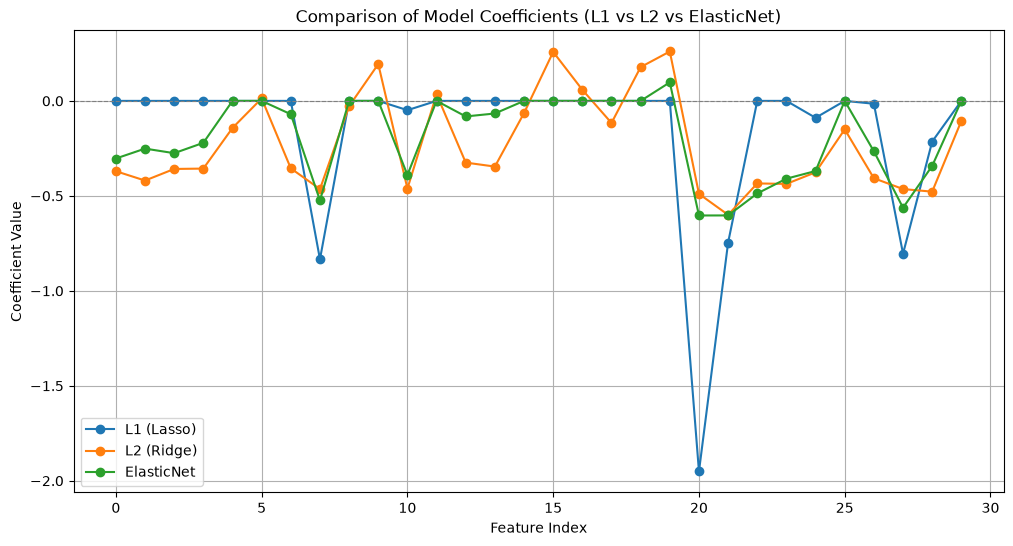

In [11]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 데이터 로드 및 전처리
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 규제 적용 전 필수 전처리: 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 모델 정의 및 학습 (L1, L2, ElasticNet)
models = {
    'L1 (Lasso)': LogisticRegression(
        penalty='l1', solver='saga', C=0.1, max_iter=5000, random_state=42
    ),
    'L2 (Ridge)': LogisticRegression(
        penalty='l2', solver='saga', C=0.1, max_iter=5000, random_state=42
    ),
    'ElasticNet': LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=0.1,
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42,
    ),
}

# 3. 모델 비교 및 결과 출력
results = {}

for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)

  acc = accuracy_score(y_test, y_pred)
  coefs = model.coef_[0]
  zero_coefs = np.sum(coefs == 0)  # 완전히 0이 된 가중치(특징) 개수

  results[name] = {
      'Accuracy': acc,
      'Zero Coef Count': zero_coefs,
      'Model': model,
  }

  print(f'=== {name} ===')
  print(f'정확도(Accuracy): {acc:.4f}')
  print(f'제거된 특징 개수(가중치=0): {zero_coefs} / {X.shape[1]}')
  print(classification_report(y_test, y_pred))

  # 모델 저장
  file_name = f'model/logistic_{name.split()[0].lower()}_model.pkl'
  joblib.dump(model, file_name)

# 4. 규제별 가중치(Coefficients) 시각화 비교
plt.figure(figsize=(12, 6))
for name, model in models.items():
  plt.plot(model.coef_[0], marker='o', label=name)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Comparison of Model Coefficients (L1 vs L2 vs ElasticNet)')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.legend()
plt.grid(True)
plt.show()